In [1]:
# Example of chaotic migration using dynamical tides operator
import rebound
import reboundx
from matplotlib import pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams.update({'font.size': 14})

# intial conditions
a0 = 1.5
e0 = 0.98
R_planet = 1.6 * 4.67e-4 # 1.6 Jupiter radii
m_planet = 1e-3 # approximately 1 Jupiter mass

# create simulation
sim = rebound.Simulation()
sim.add(m=1)
sim.add(m=m_planet, r=R_planet, a=a0, e=e0)

# load reboundx and the dynamical tides operator
rebx = reboundx.Extras(sim)
td = rebx.load_operator('tides_dynamical')
rebx.add_operator(td)

# set dP_crit = 0 to always carry out mode evolution
sim.particles[1].params['td_dP_crit'] = 0

# set initial modes to 0
sim.particles[1].params['td_c_imag'] = 0
sim.particles[1].params['td_c_real'] = 0

# debug
sim.particles[1].params['td_debug_delay'] = 0
sim.particles[1].params['td_debug_delay_counter'] = -1

# record initial orbital energy
o = sim.particles[1].orbit(primary=sim.particles[0])
EB0 = -sim.G * sim.particles[1].m * sim.particles[0].m / (2 * o.a)

N = 1000
t = np.linspace(0, 5e4, N) # time
a = np.zeros(N) # semi-major axis
e = np.zeros(N) # eccentricity
E = np.zeros(N) # mode energy
E_sim = np.zeros(N) # simulation energy
L = np.zeros((N, 3)) # total angular momentum

for i, time in enumerate(t):
    o = sim.particles[1].orbit(primary=sim.particles[0])
    a[i] = o.a
    e[i] = o.e
    L[i, :] = sim.angular_momentum() 
    E[i] = abs(EB0) * (sim.particles[1].params['td_c_imag']**2 + sim.particles[1].params['td_c_real']**2)
    E_sim[i] = sim.energy()

    if i % 2 == 0 and i != 0:
        print(time, o.a, o.e, E[i], sim.particles[1].params['td_dP_hat'])
    
    sim.integrate(2 * np.pi * time)
    



/home/dliveoak/venv/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: REBOUNDx: Operators that affect particle trajectories with adaptive timesteps can give spurious results. Use sim.ri_ias15.epsilon=0 for fixed timestep with IAS, or use a different integrator.
  warnings.warn(msg[1:], RuntimeWarning)


100.10010010010011 1.485646771140302 0.9798067710583004 3.223658354267061e-06 144.97686192599664
200.20020020020021 1.458223894809314 0.9794270242929728 9.55909557527546e-06 214.2267779188839
300.3003003003003 1.4927324344604327 0.9799026243289032 1.6245059645649361e-06 83.95183919872333
400.40040040040043 1.4622388036528304 0.9794835121229368 8.616692639048491e-06 235.39611998814084
500.50050050050055 1.4946713346250593 0.9799286951937071 1.1895382296993926e-06 107.26894937023992
600.6006006006006 1.4907269843167794 0.9798755881235995 2.0755328521441976e-06 135.74274723797436
700.7007007007007 1.4791703797626095 0.9797183581149393 4.69865783960062e-06 153.54723377056237
800.8008008008009 1.490453905991902 0.9798719009513237 2.137047615620778e-06 145.2208596526204
900.900900900901 1.469239924122873 0.9795812764618077 6.985626745385473e-06 189.1739173108414
1001.0010010010011 1.3280229724862673 0.977410025857974 4.320936057297484e-05 384.46107682762056
1101.1011011011012 1.3025371889318

KeyboardInterrupt: 

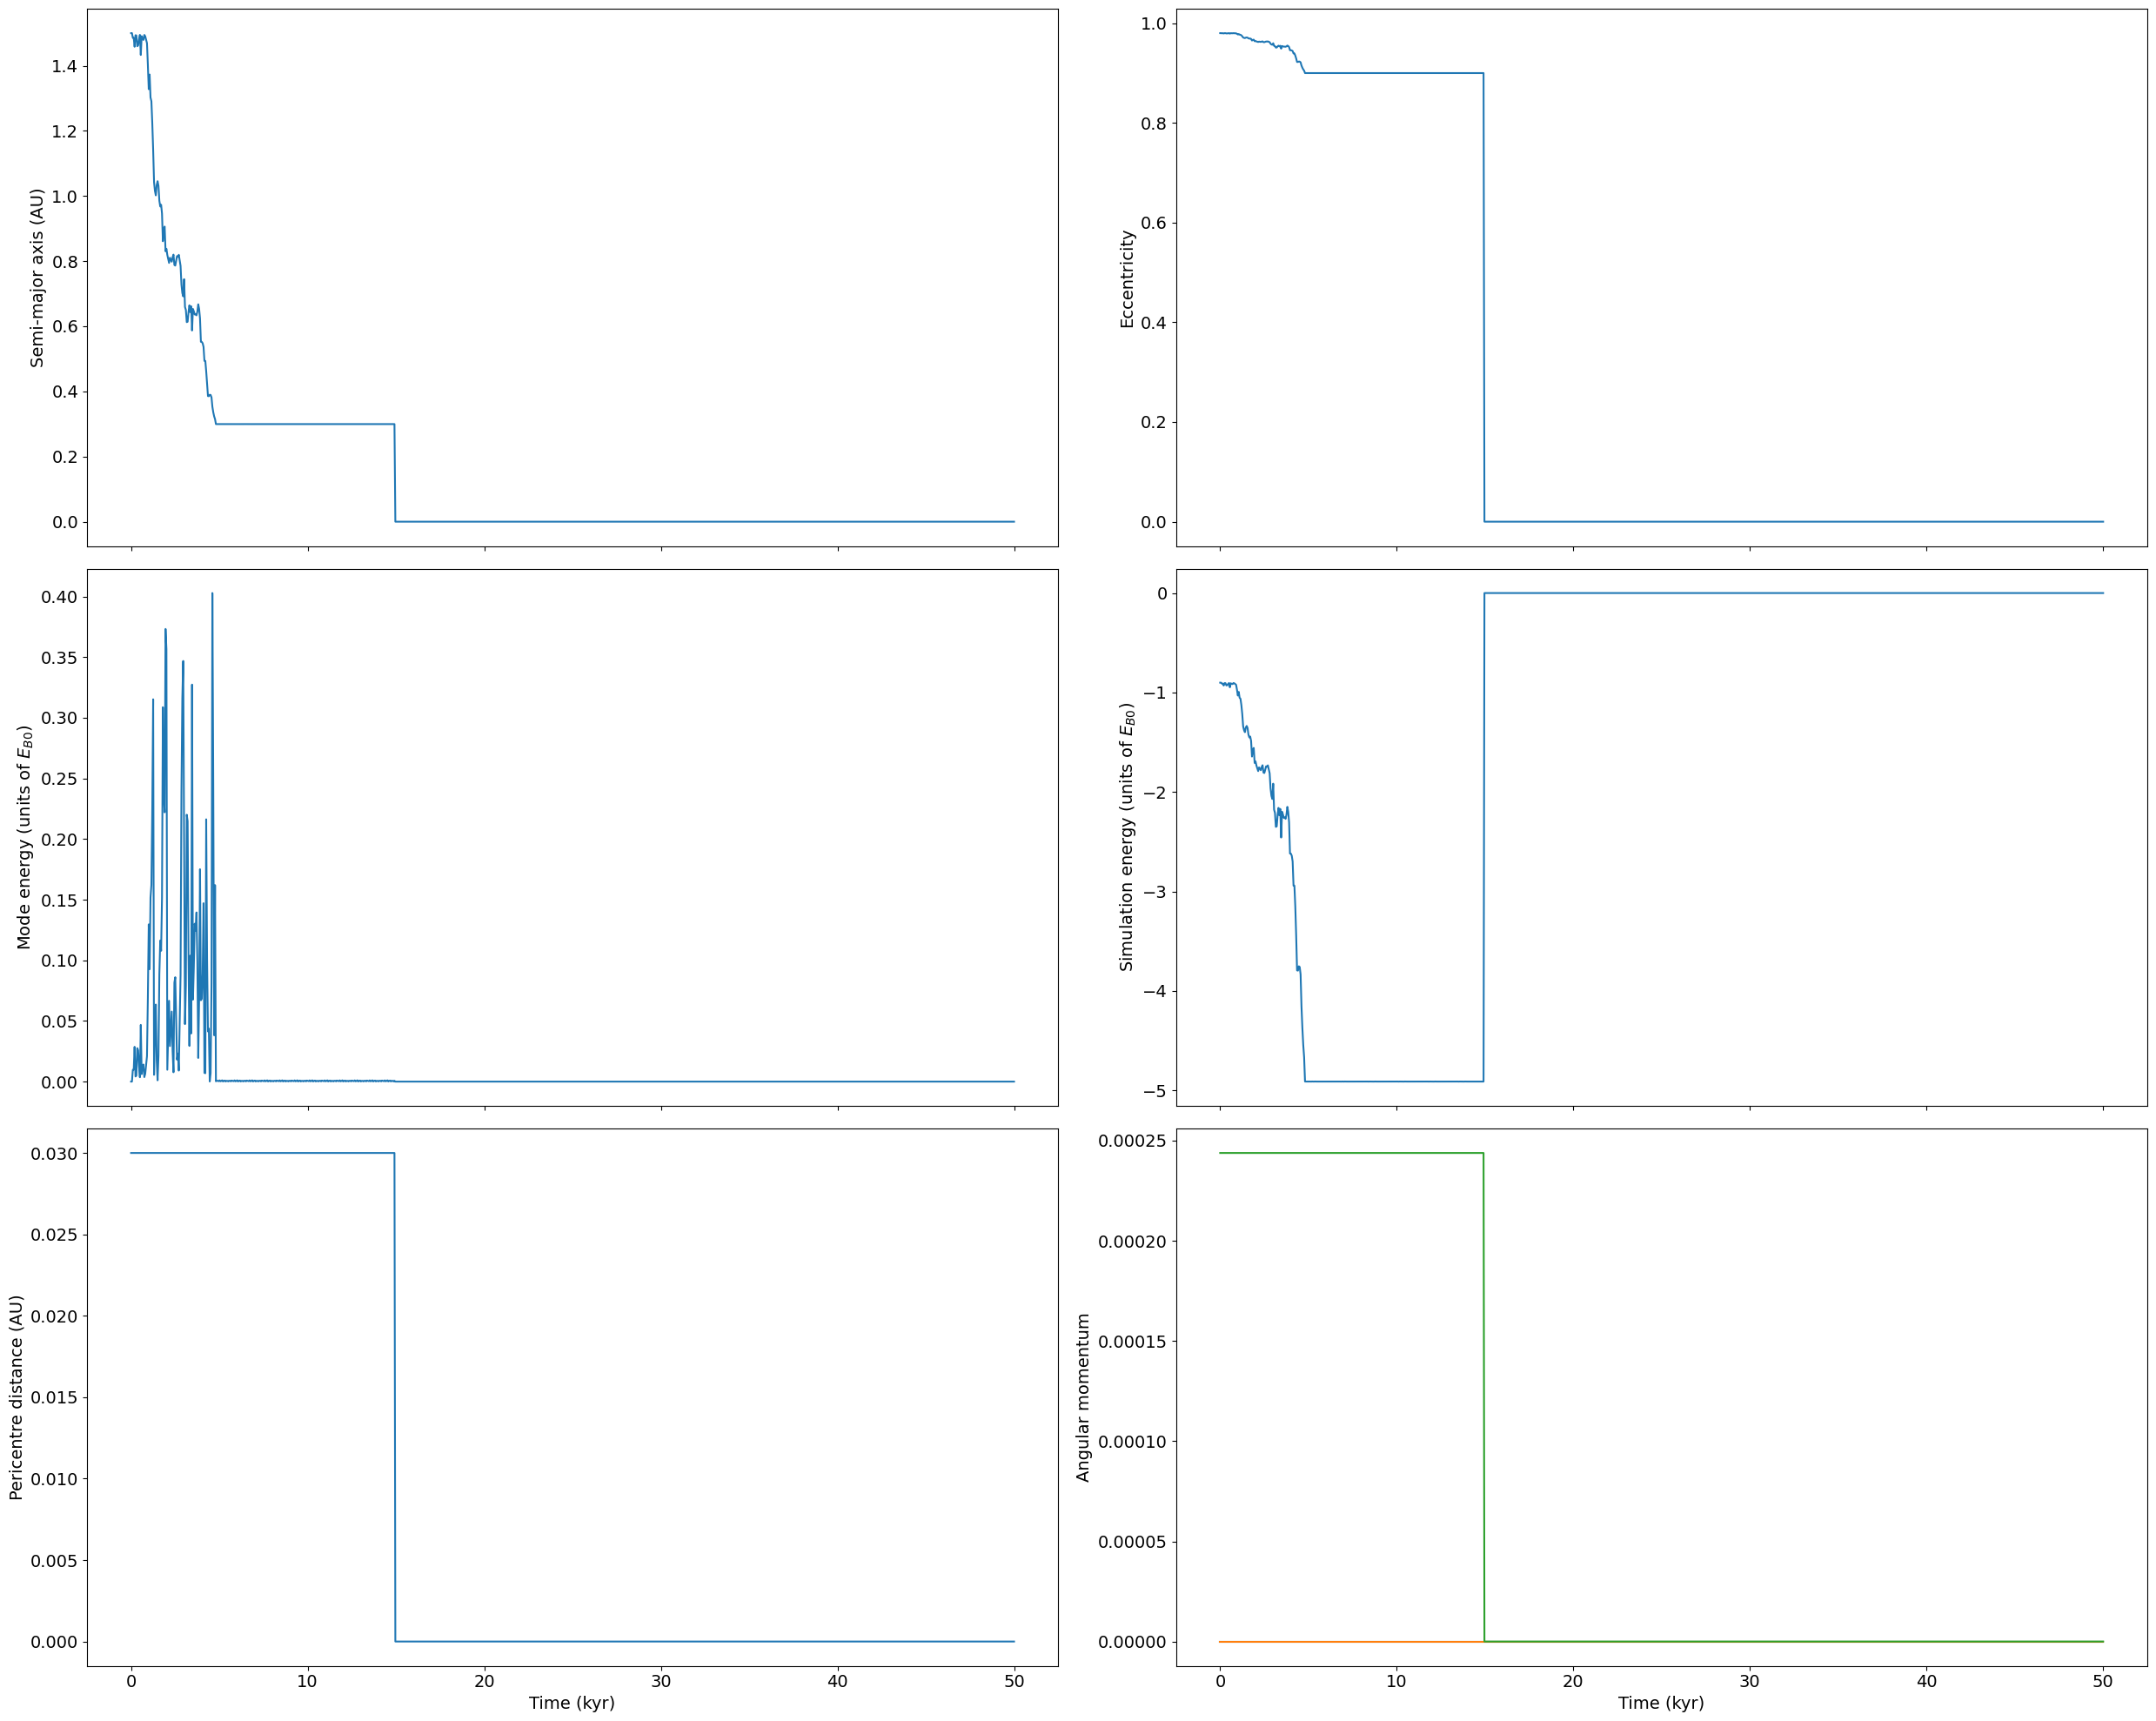

In [2]:
fig, axes = plt.subplots(3, 2, sharex=True)
fig.set_figheight(20)
fig.set_figwidth(25)


axes[0, 0].plot(t / 1e3, a)
axes[0, 0].set_ylabel(r'Semi-major axis (AU)')

axes[0, 1].plot(t / 1e3, e)
axes[0, 1].set_ylabel(r'Eccentricity')

axes[1, 0].plot(t / 1e3, -E / EB0)
axes[1, 0].set_ylabel(r'Mode energy (units of $E_{B0}$)')

axes[1, 1].plot(t / 1e3, -E_sim / EB0)
axes[1, 1].set_ylabel(r'Simulation energy (units of $E_{B0}$)')

axes[2, 0].plot(t / 1e3, a * (1-e))
axes[2, 0].set_ylabel(r'Pericentre distance (AU)')
axes[2, 0].set_xlabel(r'Time (kyr)')

axes[2, 1].plot(t / 1e3, L[:,0])
axes[2, 1].plot(t / 1e3, L[:,1])
axes[2, 1].plot(t / 1e3, L[:,2])
axes[2, 1].set_ylabel('Angular momentum')
axes[2, 1].set_xlabel(r'Time (kyr)')

plt.tight_layout()
plt.savefig("timeseries_delay_0.png", dpi=150)
